In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "Uploading_Data_Colab_1.xlsx"'.format(
      name=fn, length=len(uploaded[fn])))

Saving merged_data.csv to merged_data (1).csv
User uploaded file "Uploading_Data_Colab_1.xlsx"


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_data.csv")

df.head()


,Date,Symbol,Open,High,Low,Close,Volume,Price,Log_Volume,Volatility of Intraday Price,...,Datetime,BitcoinDominance,RegSin,RegEU,Year_x,Month_x,European_News_Index,Year_y,Month_y,SEPU
0,2019-07-05,BTC,11145.67,11406.83,10796.44,10970.73,63534.350582,9.392662,11.059336,0.042232,...,2019-07-05,64.687706,0,0,7.610358,1.94591,5.438079,7.610358,1.94591,5.676954
1,2019-07-06,BTC,10982.41,11665.00,10964.51,11256.49,51469.496331,9.341968,10.848745,0.061458,...,2019-07-06,64.722209,0,0,7.610358,1.94591,5.438079,7.610358,1.94591,5.676954
2,2019-07-07,BTC,11256.45,11538.00,11094.37,11406.24,38884.795599,9.364348,10.568359,0.037023,...,2019-07-07,64.665350,0,0,7.610358,1.94591,5.438079,7.610358,1.94591,5.676954
3,2019-07-08,BTC,11410.00,12338.03,11220.00,12238.60,52182.367215,9.353401,10.862500,0.094271,...,2019-07-08,65.215390,0,0,7.610358,1.94591,5.438079,7.610358,1.94591,5.676954
4,2019-07-09,BTC,12238.60,12794.73,12068.00,12543.41,78442.130343,9.420442,11.270116,0.056044,...,2019-07-09,66.306886,0,0,7.610358,1.94591,5.438079,7.610358,1.94591,5.676954


In [ ]:
def find_col_contains(df, keywords, prefer=None):
    cols = df.columns.tolist()
    candidates = []
    for c in cols:
        cl = c.lower()
        if all(k.lower() in cl for k in keywords):
            candidates.append(c)

    if not candidates:
        return None

    if prefer:
        for p in prefer:
            for c in candidates:
                if p.lower() in c.lower():
                    return c

    return candidates[0]

# Time column
time_col = None
if "Datetime" in df.columns:
    time_col = "Datetime"
elif "Date" in df.columns:
    time_col = "Date"

# Volume column
vol_col = "Volume" if "Volume" in df.columns else find_col_contains(df, ["volum"])

# Log volume column
logvol_col = find_col_contains(df, ["log", "vol"])

# Volatility column
vola_col = find_col_contains(df, ["volatility"], prefer=["intra", "ewma", "7d"])

# Return column
ret_col = "Return" if "Return" in df.columns else find_col_contains(df, ["return"])

print("\nDetected columns:")
print("time_col =", time_col)
print("vol_col  =", vol_col)
print("logvol_col =", logvol_col)
print("vola_col =", vola_col)
print("ret_col  =", ret_col)

if vol_col is None or vola_col is None:
    raise ValueError("Required columns not found.")



Detected columns:
time_col = Datetime
vol_col  = Volume
logvol_col = Log_Volume
vola_col = Volatility of Intraday Price
ret_col  = Return


In [ ]:

if time_col is not None:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col)

if logvol_col is None:
    df["Log_Volume"] = np.log1p(df[vol_col])
    logvol_col = "Log_Volume"

In [ ]:
eda_cols = [c for c in [time_col, "Symbol" if "Symbol" in df.columns else None,
                        vol_col, logvol_col, vola_col, ret_col] if c is not None]

eda = df[eda_cols].copy()
eda = eda.dropna(subset=[vol_col, logvol_col, vola_col])

print("\nMissing values:")
print(eda.isna().sum())


Missing values:
Datetime                        0
Symbol                          0
Volume                          0
Log_Volume                      0
Volatility of Intraday Price    0
Return                          0
dtype: int64


In [ ]:
print("\n===== Summary Statistics =====")
print(eda[[vol_col, logvol_col, vola_col] + ([ret_col] if ret_col else [])]
      .describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T)

print("\n===== Skewness =====")
print(eda[[vol_col, logvol_col, vola_col] + ([ret_col] if ret_col else [])]
      .skew(numeric_only=True))



===== Summary Statistics =====
                                count          mean           std  \
Volume                        12228.0  3.847278e+08  2.166711e+09   
Log_Volume                    12228.0  1.516639e+01  3.650806e+00   
Volatility of Intraday Price  12228.0  5.464642e-02  5.150925e-02   
Return                        12228.0  1.152997e-03  5.109486e-02   

                                      min            1%            5%  \
Volume                        7047.904300  18983.697098  35834.736971   
Log_Volume                       8.860486      9.851333     10.486673   
Volatility of Intraday Price     0.002978      0.009141      0.015199   
Return                          -0.590534     -0.129735     -0.067759   

                                        25%            50%           75%  \
Volume                        294617.329603  849812.253000  2.211288e+08   
Log_Volume                        12.593433      13.652771  1.921426e+01   
Volatility of Intraday Price

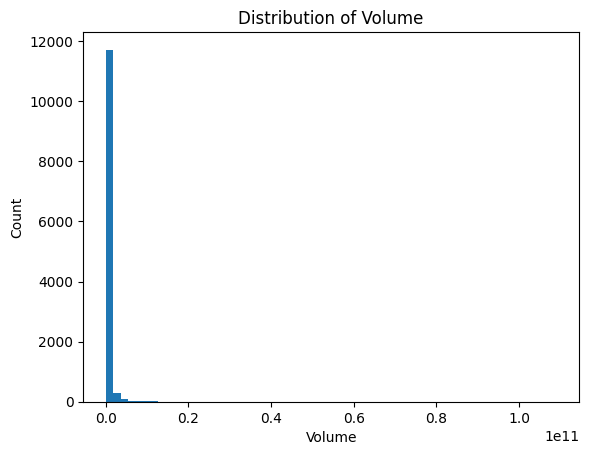

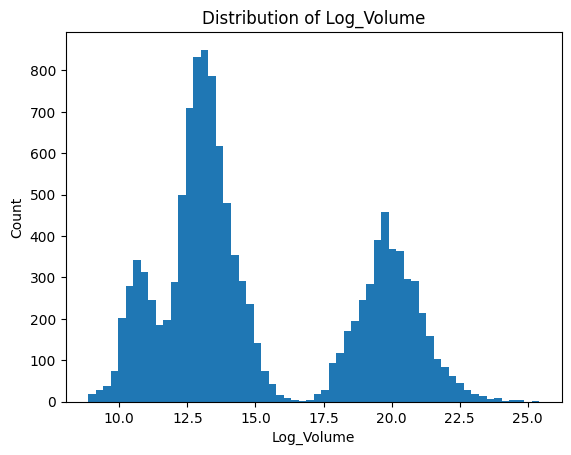

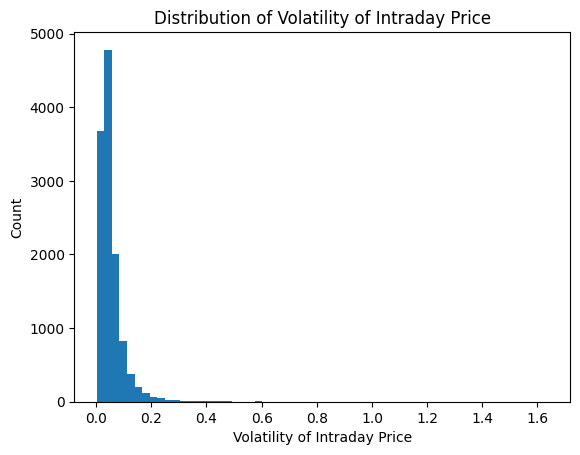

In [ ]:
plt.figure()
plt.hist(eda[vol_col], bins=60)
plt.title(f"Distribution of {vol_col}")
plt.xlabel(vol_col)
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(eda[logvol_col], bins=60)
plt.title(f"Distribution of {logvol_col}")
plt.xlabel(logvol_col)
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(eda[vola_col], bins=60)
plt.title(f"Distribution of {vola_col}")
plt.xlabel(vola_col)
plt.ylabel("Count")
plt.show()


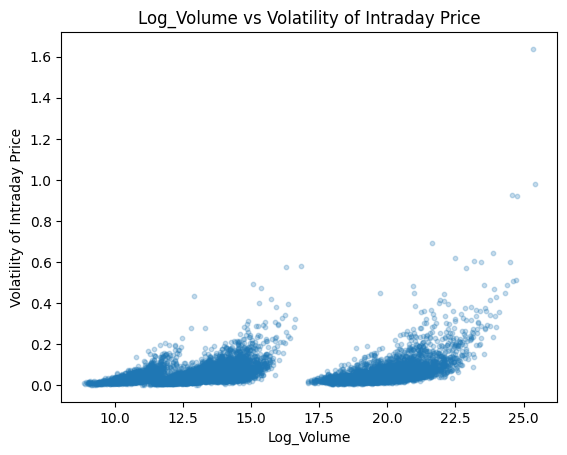


===== Correlation Matrix =====
                              Log_Volume  Volatility of Intraday Price  \
Log_Volume                      1.000000                      0.302364   
Volatility of Intraday Price    0.302364                      1.000000   
Return                          0.024224                      0.353913   

                                Return  
Log_Volume                    0.024224  
Volatility of Intraday Price  0.353913  
Return                        1.000000  


In [ ]:
plt.figure()
plt.scatter(eda[logvol_col], eda[vola_col], alpha=0.25, s=10)
plt.title(f"{logvol_col} vs {vola_col}")
plt.xlabel(logvol_col)
plt.ylabel(vola_col)
plt.show()

corr = eda[[logvol_col, vola_col] + ([ret_col] if ret_col else [])].corr(numeric_only=True)
print("\n===== Correlation Matrix =====")
print(corr)

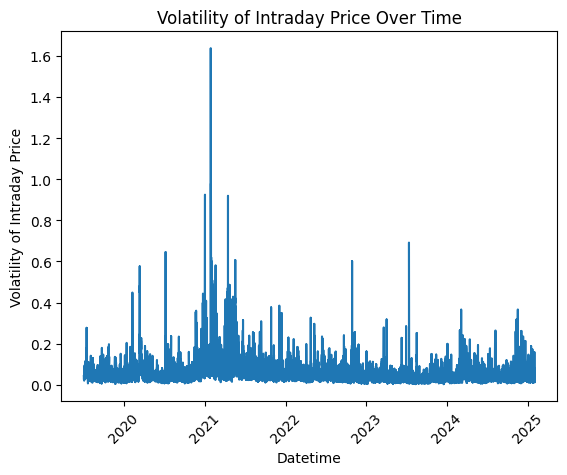

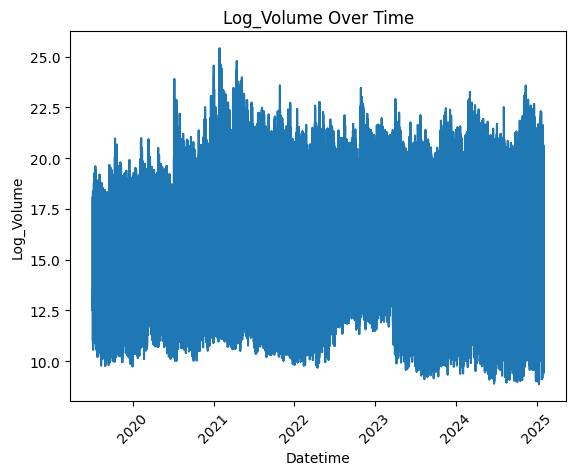

In [ ]:
if time_col is not None:
    plt.figure()
    plt.plot(eda[time_col], eda[vola_col])
    plt.title(f"{vola_col} Over Time")
    plt.xlabel(time_col)
    plt.ylabel(vola_col)
    plt.xticks(rotation=45)
    plt.show()

    plt.figure()
    plt.plot(eda[time_col], eda[logvol_col])
    plt.title(f"{logvol_col} Over Time")
    plt.xlabel(time_col)
    plt.ylabel(logvol_col)
    plt.xticks(rotation=45)
    plt.show()


===== Volume by Volatility Regime =====
                  count       mean       std        min        25%        50%  \
High_Volatility                                                                 
False            9171.0  14.642805  3.475684   8.860486  12.357223  13.248375   
True             3057.0  16.737152  3.713059  10.468589  13.759404  14.870182   

                       75%        max  
High_Volatility                        
False            18.645491  22.580433  
True             20.590615  25.415290  


/tmp/ipython-input-3992633934.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low, high], labels=["Low Vol", "High Vol"])


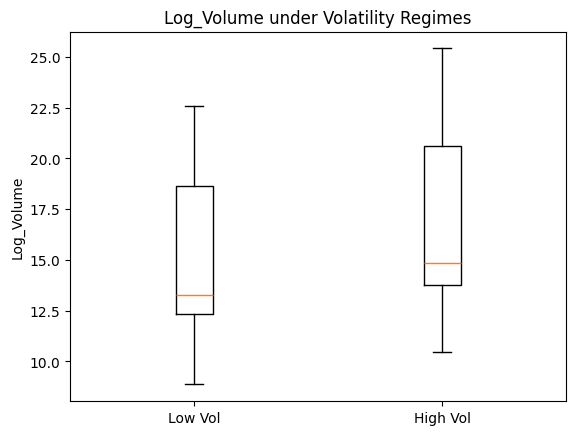

In [ ]:
q75 = eda[vola_col].quantile(0.75)
eda["High_Volatility"] = eda[vola_col] > q75

print("\n===== Volume by Volatility Regime =====")
print(eda.groupby("High_Volatility")[logvol_col].describe())

plt.figure()
low = eda.loc[~eda["High_Volatility"], logvol_col]
high = eda.loc[eda["High_Volatility"], logvol_col]
plt.boxplot([low, high], labels=["Low Vol", "High Vol"])
plt.title(f"{logvol_col} under Volatility Regimes")
plt.ylabel(logvol_col)
plt.show()

In [ ]:
extreme = eda[eda[vola_col] > eda[vola_col].quantile(0.99)]

print("\n===== Extreme Volatility Events =====")
print("Count:", len(extreme))
print(extreme[[c for c in [time_col, vola_col, vol_col, logvol_col] if c is not None]].head(10))


===== Extreme Volatility Events =====
Count: 123
        Datetime  Volatility of Intraday Price        Volume  Log_Volume
4090  2019-07-17                      0.277171  6.111251e+05   13.323057
6330  2020-02-09                      0.448802  1.307461e+09   20.991353
252   2020-03-13                      0.436467  4.022017e+05   12.904709
4330  2020-03-13                      0.495397  3.435572e+06   15.049694
8402  2020-03-13                      0.576117  1.166195e+07   16.271842
6363  2020-03-13                      0.450647  3.726479e+08   19.736145
2291  2020-03-13                      0.475398  4.663240e+06   15.355221
10441 2020-03-13                      0.481271  1.234550e+09   20.933972
6480  2020-07-08                      0.645314  2.365701e+10   23.886925
10694 2020-11-21                      0.354690  1.667090e+09   21.234345
